Các phương pháp đo độ tương đồng cơ bản

In [ ]:
#phương pháp jaccard

#đặt tham số a là chuỗi str với deffault value = " i want to go to the school"
def jaccard_sim(a: str, b: str) -> float:
    """Find the Jaccard similarity between two strings"""
    list_a = a.split(" ")
    list_b = b.split(" ")
    union = set(list_a).union(set(list_b))
    intersection = set(list_a).intersection(set(list_b))
    return len(intersection)/len(union)

In [42]:
a = " i want to go to the school"
b = " i want to go to the school"
print(jaccard_sim(a,b))

1.0


In [43]:
a_list = a.split()
bigrams = []
for i in range(0, len(a_list)-1):
    bigrams.append((a_list[i], a_list[i+1]))
print(set(bigrams))


{('want', 'to'), ('i', 'want'), ('the', 'school'), ('to', 'the'), ('to', 'go'), ('go', 'to')}


In [44]:
#phương phpas w_shingling

def w_shingling(a:str, b:str) -> float:
    """Find the w-shingling similarity between two strings"""
    a_list = a.split(" ")
    b_list = b.split(" ")
    a_shingles = set()
    b_shingles = set()
    for i in range(0, len(a_list)-1):
        a_shingles.add((a_list[i], a_list[i+1]))
    for i in range(0, len(b_list)-1):
        b_shingles.add((b_list[i], b_list[i+1]))
    union = a_shingles.union(b_shingles)
    intersection = a_shingles.intersection(b_shingles)
    return len(intersection)/len(union)

In [45]:
print(w_shingling(a,b))

1.0


In [55]:
import numpy as np
def levelshine(a: str, b: str) -> float:
    """ Find the levelshine similarity between two string"""
    a = f' {a}'
    b = f' {b}'
    level_matrix = [[0 for i in range (len(b))] for j in range(len(a))]
    level_matrix = np.asarray(level_matrix)
    for i in range(len(a)):
        for j in range(len(b)):
            if min(i,j) == 0:
                level_matrix[i,j] = max(i,j)
            else:
                min_val = min(level_matrix[i-1,j], level_matrix[i,j-1], level_matrix[i-1,j-1])
                if a[i] != b[j]:
                    min_val +=1
                level_matrix[i,j] = min_val
    return level_matrix, level_matrix[-1,-1]

In [57]:
matrix, value = levelshine("Levenshtein","Levenshtein")
print(value)
print(matrix)

0
[[ 0  1  2  3  4  5  6  7  8  9 10 11]
 [ 1  0  1  2  3  4  5  6  7  8  9 10]
 [ 2  1  0  1  1  2  3  4  5  5  6  7]
 [ 3  2  1  0  1  2  3  4  5  6  6  7]
 [ 4  3  1  1  0  1  2  3  4  4  5  6]
 [ 5  4  2  2  1  0  1  2  3  4  5  5]
 [ 6  5  3  3  2  1  0  1  2  3  4  5]
 [ 7  6  4  4  3  2  1  0  1  2  3  4]
 [ 8  7  5  5  4  3  2  1  0  1  2  3]
 [ 9  8  5  6  4  4  3  2  1  0  1  2]
 [10  9  6  6  5  5  4  3  2  1  0  1]
 [11 10  7  7  6  5  5  4  3  2  1  0]]


Các phương pháp tính Similarity search dựa trên véc tơ

In [37]:
#TF - IDF
# docs là list của list các câu trong mỗi doc
import numpy as np
a = "purple is the best city in the forest".split()
b = "there is an art to getting in your way and throwing bananas".split()
c = "it is not often you find soggy bananas on the street".split()
docs = [a,b,c]
def tf_idf(word: str, sentence: str) -> float:
    """Count the tf_idf of a word in the sentence"""
    tf = sentence.split().count(word)/len(sentence.split())
    df = sum([1 for doc in docs if word in doc])
    idf = np.log10(len(docs)/sum([1 for doc in docs if word in doc]))
    return round(tf*idf,4)

In [38]:
tf_idf("forest",(" ").join(a))

0.0596

In [39]:
vocab = set(a+ b+ c) #tập hợp các từ vựng
vocab

{'an',
 'and',
 'art',
 'bananas',
 'best',
 'city',
 'find',
 'forest',
 'getting',
 'in',
 'is',
 'it',
 'not',
 'often',
 'on',
 'purple',
 'soggy',
 'street',
 'the',
 'there',
 'throwing',
 'to',
 'way',
 'you',
 'your'}

In [44]:
vec_a = []
vec_b = []
vec_c= []
a = "purple is the best city in the forest"
b = "there is an art to getting in your way and throwing bananas"
c = "it is not often you find soggy bananas on the street"
for word in vocab:
    vec_a.append(tf_idf(word,a))
    vec_b.append(tf_idf(word,b))
    vec_c.append(tf_idf(word,c))

In [45]:
print(tf_idf("an",a))

0.0


In [46]:
vec_a #véc tơ representation của a

[0.0596,
 0.0,
 0.0596,
 0.0596,
 0.0,
 0.0596,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.022,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.044,
 0.0,
 0.0,
 0.0]

In [47]:
a = "purple is the best city in the forest".split()
b = "there is an art to getting in your way and throwing bananas".split()
c = "it is not often you find soggy bananas on the street".split()
d = "green should have smelled more tranquil but somehow it just tasted rotten".split()
e = "joyce enjoyed eating pancakes with ketchup".split()
f = "as the asteroid hurtled toward earch becky was upset her dentist appointment had been cancelled".split()

In [48]:
docs = [a,b,c,d,e,f]

In [50]:
d_avg = sum([len(doc) for doc in docs])/len(docs)

In [66]:
def bm25(word: str, sentence: str, k: float = 1.2, b: float = 0.75) -> float:
    """Count the bm25 of the word in the given sentence"""
    f_q_D = sentence.split().count(word)
    D = len(sentence.split())
    tf = (f_q_D * (k + 1)) / (f_q_D + k * (1 - b + b * (D / d_avg)))
    N = len(docs)
    N_q = sum([1 for doc in docs if word in doc])
    idf = np.log(((N - N_q + 0.5) / (N_q + 0.5)) + 1)
    return round(tf * idf,4)

In [67]:
bm25("purple"," ".join(a))

1.7159

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity


array([[1.]])

In [98]:
a = "purple is the best city in the forest"
b = "there is an art to getting in your way and throwing bananas"
c = "it is not often you find soggy bananas on the street"
d = "green should have smelled more tranquil but somehow it just tasted rotten"
e = "joyce enjoyed eating pancakes with ketchup"
f = "as the asteroid hurtled toward earch becky was upset her dentist appointment had been canceled"
g = "to get your way you must not bombard the road with yellow fruit"

In [99]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("bert-base-nli-mean-tokens")

In [100]:
sentences = [a,b,c,d,e,f,g]

In [101]:
sentence_embeddings = model.encode(sentences)
sentence_embeddings.shape

(7, 768)

In [ ]:
similarity_matrix = np.zeros(shape = (len(sentences),len(sentences)))

In [103]:
for i in range(len(sentences)):
    for j in range(len(sentences)):
        similarity_matrix[i,j] = cosine_similarity([sentence_embeddings[i]],[sentence_embeddings[j]]).item()

<Axes: >

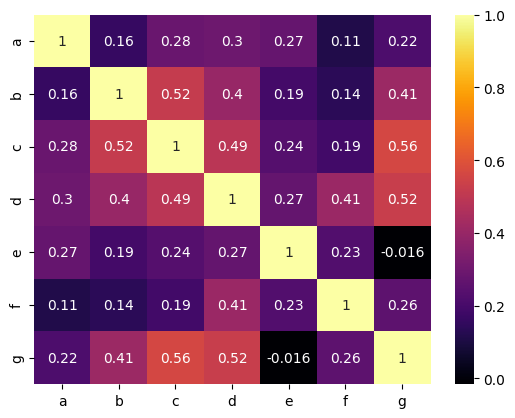

In [104]:
import seaborn as sns
sns.heatmap(data = similarity_matrix,xticklabels= ["a","b","c","d","e","f","g"],yticklabels=["a","b","c","d","e","f","g"],annot= True,cmap = "inferno")

FAISS: một véc tơ database

In [2]:
from sentence_transformers import SentenceTransformer
#load model Bert Transformers dùng để embedding câu ra chiều 768
model = SentenceTransformer(model_name_or_path= "bert-base-nli-mean-tokens")

In [12]:
import numpy as np
for i in range(57):
    if i==0:
        with open(f"data-main/sentence_embeddings_15k/embeddings_{i}.npy", "rb") as fp:
            sentence_embeddings = np.load(fp)
    else:
        with open(f"data-main/sentence_embeddings_15k/embeddings_{i}.npy", "rb") as fp: 
            sentence_embeddings = np.append(arr = sentence_embeddings, values = np.load(fp),axis = 0)

In [13]:
sentence_embeddings.shape

(14504, 768)

In [53]:
with open("data-main/sentence_embeddings_15k/sentences.txt", "r",encoding = "utf-8") as fp: #so khớp với sentences ban đầu
    sentences = fp.read().split("\n")

In [20]:
#input một câu mới và embedding sử dụng model bert
query = "hello word"
model.encode(query).shape

(768,)

In [78]:
#indexflatl2
d = sentence_embeddings.shape[1]
import faiss #tạo một faiss véc tơ database
index = faiss.IndexFlatL2(d) #tạo một faiss với chỉ mục sử dụng indexflatl2

In [79]:
index.is_trained #giúp kiểm tra xem index có cần được train không (chỉ khi train xong mới sẵn sàng add dữ liệu vào)

True

In [80]:
#add các embeddings vào trong index
index.add(sentence_embeddings)

In [81]:
index.ntotal #xem số véc tơ trong database

14504

In [ ]:
%%time
xq = model.encode(["someone sprints with a football"])
# sử dụng hàm search để retrieve véc tơ
D, I = index.search(xq, 4) 
#D: trả về khoảng cách giữa retrieve và query
#I: trả về các stt véc tơ được retrieve

CPU times: total: 46.9 ms
Wall time: 42.7 ms


In [85]:
print(I)

[[ 4586 10252 12465   190]]


In [86]:
for i in I[0]:
    print(f"{i}: {sentences[i]}")

4586: A group of football players is running in the field
10252: A group of people playing football is running in the field
12465: Two groups of people are playing football
190: A person playing football is running past an official carrying a football


In [87]:
#sử dụng paritition giúp search nhanh hơn
nlist = 50 #định nghĩa số vùng ta muốn chia
quantizer = faiss.IndexFlatL2(d) #do ta vẫn sử dụng l2 distance => cần tạo quantizer
index = faiss.IndexIVFFlat(quantizer,d,nlist) #tạo parition với 50 vùng. khi search ta dùng quantizer

In [88]:
index.is_trained #false: => cần train với dữ liệu

False

In [89]:
index.train(sentence_embeddings) #truyền dataset của ta vào để tự động train

In [90]:
index.is_trained

True

In [91]:
index.add(sentence_embeddings)

In [111]:
%%time
xq = model.encode(["someone sprints with a football"])
# sử dụng hàm search để retrieve véc tơ
D, I = index.search(xq, 4) #có thể thấy thời gian search sẽ nhanh hơn
#D: trả về khoảng cách giữa retrieve và query
#I: trả về các stt véc tơ được retrieve


CPU times: total: 46.9 ms
Wall time: 42.6 ms


In [104]:
for i in I[0]:
    print(f"{i}: {sentences[i]}")

4586: A group of football players is running in the field
10252: A group of people playing football is running in the field
12465: Two groups of people are playing football
190: A person playing football is running past an official carrying a football


In [ ]:
index.nprobe = 10 #số vùng gần nhất sẽ được search (mặc định là 1 - chỉ xét một vùng gần nhất xq)

In [114]:
%%time
xq = model.encode(["someone sprints with a football"])
# sử dụng hàm search để retrieve véc tơ
D, I = index.search(xq, 4) #có thể thấy thời gian search sẽ nhanh hơn
#D: trả về khoảng cách giữa retrieve và query
#I: trả về các stt véc tơ được retrieve

CPU times: total: 31.2 ms
Wall time: 45.3 ms


In [ ]:
#product quantization
m = 8 #số phân đoạn ta muốn chia véc tơ
bits = 8 #bits: số centeroids ta sử dụng cho mỗi phân đoạn => 8 bits nghĩa là mỗi phân đoạn sẽ được mã hóa thành số từ 0 => 255

quantizer = faiss.IndexFlatL2(d)
index = faiss.IndexIVFPQ(quantizer,d,nlist,m,bits) #không lưu véc tơ theo kiểu flat nữa mà lưu véc tơ theo kiểu product quantization
#nlist: số vùng ta muốn chia véc tơ ra
#quantizer: phương pháp đó khoảng cách


In [123]:
index.is_trained

False

In [124]:
index.train(sentence_embeddings)

In [125]:
index.add(sentence_embeddings)

In [126]:
index.ntotal

14504

In [127]:
%%time
xq = model.encode(["someone sprints with a football"])
# sử dụng hàm search để retrieve véc tơ
D, I = index.search(xq, 4) #có thể thấy thời gian search sẽ nhanh hơn
#D: trả về khoảng cách giữa retrieve và query
#I: trả về các stt véc tơ được retrieve

CPU times: total: 31.2 ms
Wall time: 43.1 ms


In [131]:
for i in I[0]:
    print(f"{i}: {sentences[i]}")

190: A person playing football is running past an official carrying a football
399: A football player kicks the ball.
8328: A football player is running past an official carrying a football
12465: Two groups of people are playing football


Một số loại index khác

In [1]:
import shutil
import urllib.request as request
from contextlib import closing

# first we download the Sift1M dataset
with closing(request.urlopen('ftp://ftp.irisa.fr/local/texmex/corpus/sift.tar.gz')) as r:
    with open('sift.tar.gz', 'wb') as f:
        shutil.copyfileobj(r, f)

In [3]:
import tarfile

# the download leaves us with a tar.gz file, we unzip it
tar = tarfile.open('sift.tar.gz', "r:gz")
tar.extractall()
import numpy as np

# now define a function to read the fvecs file format of Sift1M dataset
def read_fvecs(fp):
    a = np.fromfile(fp, dtype='int32')
    d = a[0]
    return a.reshape(-1, d + 1)[:, 1:].copy().view('float32')
# data we will search through
xb = read_fvecs("sift\sift_base.fvecs")  # 1M samples
# also get some query vectors to search with
xq = read_fvecs('./sift/sift_query.fvecs')
# take just one query (there are many in sift_learn.fvecs)
xq = xq[0].reshape(1, xq.shape[1])

<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Admin\AppData\Local\Temp\ipykernel_15496\4223037301.py:14: SyntaxWarning: invalid escape sequence '\s'
  xb = read_fvecs("sift\sift_base.fvecs")  # 1M samples
C:\Users\Admin\AppData\Local\Temp\ipykernel_15496\4223037301.py:5: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


In [1]:
import faiss
d = xb.shape[1]
#flatL2 hay flatip sẽ đảm bảo ra được giá trị nhỏ nhất

index = faiss.IndexFlatIP(d)
index.is_trained

NameError: name 'xb' is not defined

In [26]:
index.add(xb)
index.ntotal

1000000

In [34]:
%%time
D,I = index.search(xq,10)

CPU times: total: 31.2 ms
Wall time: 22.3 ms


In [ ]:
baseline = I[0].tolist() #lấy làm đáp án chuẩn để so sánh với các phương pháp khác

In [ ]:
#Locality Sentitive Hashing (LSH)
nbits = d*4  #tạo ra binary véc tơ với độ dài 4*d
#tăng nbits sẽ tăng độ chính xác nhưng sẽ làm chậm quá trình tìm kiếm
index = faiss.IndexLSH(d, nbits)
index.is_trained #không cần train

True

In [39]:
index.add(xb)
index.ntotal

1000000

In [ ]:
%%time
D, I = index.search(xq, 10) #thời gian chạy nhanh hơn rất nhiều so với flatL2

CPU times: total: 0 ns
Wall time: 5.23 ms


In [42]:
#đo độ chính xác
correct = 0
for i in I[0].tolist():
    if i in baseline:
        correct += 1
print(f"Độ chính xác của LSH: {correct/10*100}%")

Độ chính xác của LSH: 60.0%


In [45]:
#HNSW
M = 16 #số cạnh trung bình của mỗi nút trong đồ thị
ef_search = 32 #số nút được duyệt khi tìm kiếm
ef_construction = 64 #số cạnh được thêm vào mỗi nút khi xây dựng đồ thị
index = faiss.IndexHNSWFlat(d, M)
index.hnsw.efSearch = ef_search
index.hnsw.efConstruction = ef_construction
index.add(xb)

In [51]:
%%time
D, I = index.search(xq, 10) #nhanh hơn so với LSH

CPU times: total: 0 ns
Wall time: 1.07 ms


In [52]:
correct = 0
for i in I[0].tolist():
    if i in baseline:
        correct += 1
print(f"Độ chính xác của HNSW: {correct/10*100}%")

Độ chính xác của HNSW: 70.0%


In [8]:
a = "flying fish flew by the space station"
b = "he will not allow you to bring your sticks of dynamite and pet"
c = "he figured a few sticks of dynamite were easier than a fishing pole to carry around"

In [9]:
def shingle(sentence: str, k: int =3) -> set:
    """Create k-shingles from a given sentence"""
    shingles = set()
    for i in range(len(sentence)-k+1):
        shingles.add(sentence[i:i+k])
    return shingles

In [13]:
k = 2
a = shingle(a,k)
b = shingle(b,k)
c = shingle(c,k)

In [16]:
vocab = list(a.union(b).union(c))

In [17]:
#chuyển thành enhotencoding
a_onehot = [1 if i in a else 0 for i in vocab]
b_onehot = [1 if i in b else 0 for i in vocab]
c_onehot = [1 if i in c else 0 for i in vocab]

In [51]:
hash_ex = list(range(1,len(vocab)+1))

In [52]:
#import shuffle
from random import shuffle
shuffle(hash_ex)
hash_ex

[78,
 89,
 33,
 61,
 101,
 70,
 10,
 94,
 93,
 63,
 6,
 40,
 18,
 30,
 92,
 11,
 69,
 84,
 98,
 26,
 97,
 67,
 51,
 58,
 19,
 53,
 55,
 90,
 17,
 99,
 96,
 56,
 5,
 88,
 27,
 80,
 44,
 31,
 50,
 74,
 7,
 82,
 2,
 73,
 48,
 79,
 77,
 8,
 52,
 9,
 13,
 85,
 42,
 25,
 38,
 64,
 81,
 47,
 95,
 15,
 22,
 91,
 46,
 68,
 76,
 29,
 28,
 36,
 32,
 35,
 39,
 75,
 83,
 16,
 4,
 3,
 41,
 24,
 54,
 66,
 23,
 87,
 45,
 34,
 12,
 100,
 60,
 65,
 20,
 49,
 21,
 1,
 37,
 59,
 43,
 57,
 72,
 14,
 86,
 71,
 62]

In [53]:
for i in range(1,10):
    print(f"{i}: {hash_ex.index(i)}")

1: 91
2: 42
3: 75
4: 74
5: 32
6: 10
7: 40
8: 47
9: 49


In [54]:
for i in range(1,len(vocab)+1):
   index = hash_ex.index(i)
   signature = a_onehot[index]
   print(f"{i} -> {hash_ex.index(i)} -> {signature}")
   if signature == 1:
       print("Match found")
       break

1 -> 91 -> 1
Match found


In [55]:
#tạo hàm nbits hàm min hash để sinh ra véc tơ có độ dài nbits
def create_hash_func(size: int = len(vocab)) -> list:
    """Create a hash function that maps the input to a random permutation of integers"""
    hash_func = list(range(1,size+1))
    shuffle(hash_func)
    return hash_func

def build_min_hash_func(size:int, nbits:int) -> list:
    """Build multiple hash functions to create a min hash signature"""
    hash_funcs = []
    for _ in range(nbits):
        hash_funcs.append(create_hash_func(size))
    return hash_funcs

#create 20 minhash functions
min_hash_funcs = build_min_hash_func(size = len(vocab), nbits = 20)

In [58]:
#tạo create_signature để tạo ra signature cho một câu
def create_signature(min_hash_funcs: list, onehot: list) -> list:
    """Function to create a min hash signature for a given onehot encoding"""
    signature = []
    for func in min_hash_funcs:
        for i in range(1,len(vocab)+1):
            index = func.index(i)
            sig = onehot[index]
            if sig == 1:
                signature.append(index)
                break
    return signature

In [59]:
a_sig = create_signature(min_hash_funcs, a_onehot)
b_sig = create_signature(min_hash_funcs, b_onehot)
c_sig = create_signature(min_hash_funcs, c_onehot)
print(a_sig)
print(b_sig)
print(c_sig)

[16, 4, 57, 51, 84, 63, 79, 57, 32, 25, 91, 86, 91, 32, 47, 81, 75, 5, 47, 0]
[44, 2, 98, 27, 24, 63, 69, 29, 98, 22, 36, 49, 20, 73, 92, 81, 75, 49, 11, 70]
[58, 2, 39, 27, 96, 63, 69, 29, 59, 25, 91, 19, 34, 40, 30, 31, 88, 49, 11, 51]


In [60]:
def jaccard_sim(a:list, b:list) -> float:
    """Find the Jaccard similarity between two sets"""
    a = set(a)
    b = set(b)
    union = a.union(b)
    intersection = a.intersection(b)
    return len(intersection)/len(union)

In [ ]:
print(jaccard_sim(a_sig,b_sig), jaccard_sim(a,b)) #có thể thấy hàm signature có tương đồng với hàm gốc
print(jaccard_sim(c_sig,b_sig), jaccard_sim(c,b))

0.0967741935483871 0.14473684210526316
0.22580645161290322 0.4090909090909091


In [74]:
def build_sub_vecto(signature: list, b: int) -> list:
    """Build sub-vectors from a given signature"""
    if len(signature) % b != 0:
        raise ValueError("Signature length must be divisible by band size")
    sub_vectors = []
    band_size = int(len(signature)/b)
    for i in range(0, len(signature), band_size):
        sub_vectors.append(signature[i:i+band_size])
    return sub_vectors

In [76]:
a_band = build_sub_vecto(a_sig, 10)
b_band = build_sub_vecto(b_sig, 10)
c_band = build_sub_vecto(c_sig, 10)

In [78]:
#so sánh, ta chỉ cần 1 band match là có thể coi hai câu có tương đồng
for b_rows, c_rows in zip(b_band, c_band):
    if b_rows == c_rows:
        print(f"Candidate pair: {b_rows} == {c_rows}")
        print("Match found")
        break

Candidate pair: [69, 29] == [69, 29]
Match found


In [80]:
for a_rows, b_rows in zip(a_band, b_band):
    if a_rows == b_rows:
        print(f"Candidate pair: {a_rows} == {b_rows}")
        print("Match found")
        break

In [81]:
for a_rows, c_rows in zip(a_band, c_band):
    if a_rows == c_rows:
        print(f"Candidate pair: {a_rows} == {c_rows}")
        print("Match found")
        break

In [ ]:
#bản chất của LSH trong faiss (sử dụng hyperplane)
import numpy as np
import faiss
d = 2 #số chiều của không gian véc tơ
nbits = 4 #số bit trong binary véc tơ (số hyperplane), nbits càng lớn thì độ chính xác càng cao nhưng thời gian tìm kiếm càng lâu

hyperplane = np.random.rand(nbits,d) - 0.5
hyperplane

array([[-0.24104994,  0.06574318],
       [-0.17977156,  0.41318452],
       [-0.46655669,  0.19699951],
       [-0.108846  , -0.43433868]])

In [11]:
a = np.array([1,2])
b = np.array([2,1])
c = np.array([3,1])

In [12]:
result = np.dot(a,hyperplane.T)

In [ ]:
result #binary của query này sẽ là [0,1,0,0]

array([-0.10956358,  0.64659748, -0.07255767, -0.97752336])

In [16]:
a_dot = np.dot(a,hyperplane.T)
b_dot = np.dot(b,hyperplane.T)
c_dot = np.dot(c,hyperplane.T)

In [ ]:
a_dot = a_dot>0
b_dot = b_dot>0
c_dot = c_dot>0
a_dot = a_dot.astype(int)
b_dot = b_dot.astype(int)
c_dot = c_dot.astype(int)

In [19]:
hash_dict = {}
vectors = [a_dot, b_dot, c_dot]

for i in range(len(vectors)):
    hash_key = "".join(vectors[i].astype(str))
    if hash_key not in hash_dict:
        hash_dict[hash_key] = []
    hash_dict[hash_key].append(i)

In [ ]:
hash_dict #dictionary lưu véc tơ theo từng bucket

{'0100': [0, 1], '0000': [2]}

In [ ]:
#ứng dụng index lsh trong faiss
import numpy as np
def read_fvecs(fp):
    a = np.fromfile(fp, dtype='int32')
    d = a[0]
    return a.reshape(-1, d + 1)[:, 1:].copy().view('float32')

xb = read_fvecs("sift\sift_base.fvecs")
xq = read_fvecs('sift\sift_query.fvecs')[0].reshape(1,-1)

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Admin\AppData\Local\Temp\ipykernel_17580\2168088389.py:7: SyntaxWarning: invalid escape sequence '\s'
  xb = read_fvecs("sift\sift_base.fvecs")
C:\Users\Admin\AppData\Local\Temp\ipykernel_17580\2168088389.py:8: SyntaxWarning: invalid escape sequence '\s'
  xq = read_fvecs('sift\sift_query.fvecs')[0].reshape(1,-1)


In [ ]:
xb.shape

(1000000, 128)

In [38]:
nbits = 4 #tạo 4 hyperplane
d = xb.shape[1]
index = faiss.IndexLSH(d, nbits)
index.is_trained

True

In [39]:
index.add(xb)
index.ntotal

1000000

In [51]:
k = 10
D,I = index.search(xq,k)

In [57]:
I

array([[ 0,  2,  6, 25, 26, 43, 47, 70, 73, 74]], dtype=int64)

In [53]:
D #in ra giá trị hamming distance

array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
results = cosine_similarity(xb[I[0]],xq)
results.mean() #trung bình giá trị cosine similarity

0.44347006

In [ ]:
results_all = cosine_similarity(xb,xq)
results_all.mean() #có thể thấy giá trị ở trên tốt hơn chút so với giá trị trung bình (mặc dù ta sử dụng nbits rất thấp)

0.4223302

In [ ]:
#estimate số lượng trung bình bucket dựa vào nbits
for nbits in [2,4,5,16,24,32]:
    buckets = 2**nbits
    print(f"nbits = {nbits}")
    print(f"{xb.shape[0]}/ {buckets} = {xb.shape[0]/buckets}")

nbits = 2
1000000/ 4 = 250000.0
nbits = 4
1000000/ 16 = 62500.0
nbits = 5
1000000/ 32 = 31250.0
nbits = 16
1000000/ 65536 = 15.2587890625
nbits = 24
1000000/ 16777216 = 0.059604644775390625
nbits = 32
1000000/ 4294967296 = 0.00023283064365386963


In [88]:
#xét độ chính xác dựa trên từng tham số nbits
for nbits in [2,4,8,16,24,32]:
    index = faiss.IndexLSH(d,nbits)
    index.add(xb)
    D, I = index.search(xq,10)
    results = cosine_similarity(xb[I[0]],xq)
    results_all = cosine_similarity(xb,xq)
    print("------------------------------------------")
    print(f"nbits = {nbits}")
    print( f"{k} vectors found: {results.mean()}")
    print( f"Whole vector database: {results_all.mean()}") #có thể thấy, ta đặt nbits = 24 đạt độ chinh xác cao nhất

------------------------------------------
nbits = 2
10 vectors found: 0.41090115904808044
Whole vector database: 0.42233020067214966
------------------------------------------
nbits = 4
10 vectors found: 0.4434700608253479
Whole vector database: 0.42233020067214966
------------------------------------------
nbits = 8
10 vectors found: 0.6331983804702759
Whole vector database: 0.42233020067214966
------------------------------------------
nbits = 16
10 vectors found: 0.6283484697341919
Whole vector database: 0.42233020067214966
------------------------------------------
nbits = 24
10 vectors found: 0.7387701869010925
Whole vector database: 0.42233020067214966
------------------------------------------
nbits = 32
10 vectors found: 0.7063198089599609
Whole vector database: 0.42233020067214966


In [89]:
nbits = 4
index = faiss.IndexLSH(d,nbits)
index.add(xb)

In [92]:
arr = faiss.vector_to_array(index.codes) #index.codes: lưu trữ các mã hóa nhị phân của LSH hoặc mã hóa Product Quantization của các véc tơ được add vào index

In [ ]:
arr #list lưu bucket được lưu của mỗi véc tơ

array([ 5, 12,  5, ..., 15, 13, 12], dtype=uint8)

In [102]:
#hàm biến đổi từ véc tơ int sang nhị phân
bin_vecs = (((arr[:,None]& (1<<np.arange(nbits))[::-1]))>0).astype(int)
bin_vecs

array([[0, 1, 0, 1],
       [1, 1, 0, 0],
       [0, 1, 0, 1],
       ...,
       [1, 1, 1, 1],
       [1, 1, 0, 1],
       [1, 1, 0, 0]])

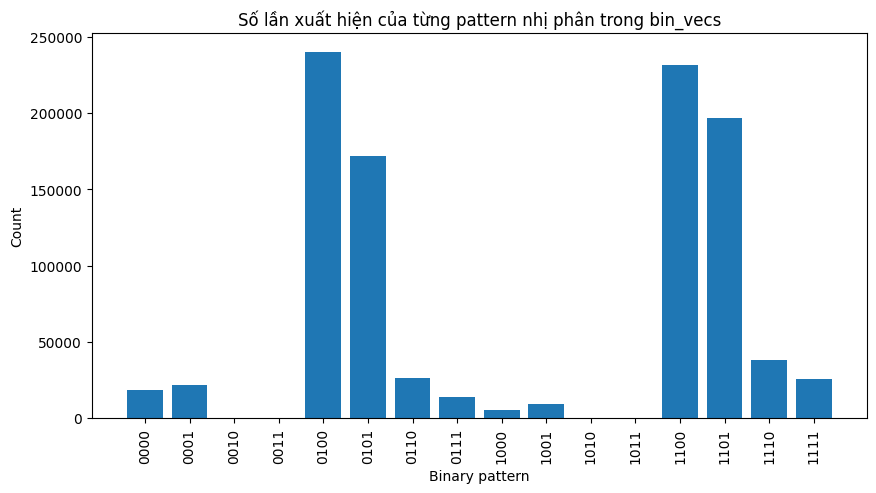

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

def plot_bin_vecs_pattern_count(bin_vecs):
    """
    Đếm và visualize số lần xuất hiện của từng pattern nhị phân trong bin_vecs.
    """
    # Chuyển từng hàng thành tuple để đếm
    patterns = [tuple(row) for row in bin_vecs]
    counter = Counter(patterns)
    
    # Sắp xếp theo giá trị nhị phân (từ 0...0 đến 1...1)
    nbits = bin_vecs.shape[1]
    all_patterns = [tuple(map(int, f"{i:0{nbits}b}")) for i in range(2**nbits)]
    counts = [counter.get(p, 0) for p in all_patterns]
    labels = [''.join(map(str, p)) for p in all_patterns]

    plt.figure(figsize=(max(10, len(labels)*0.6), 5))
    plt.bar(labels, counts)
    plt.xlabel('Binary pattern')
    plt.ylabel('Count')
    plt.title('Số lần xuất hiện của từng pattern nhị phân trong bin_vecs')
    plt.xticks(rotation=90)
    plt.show()


plot_bin_vecs_pattern_count(bin_vecs) #có thể thấy các số lượng phân bố không dều (maximize collision)

Bản chất của Product Quantization

In [ ]:

x = [1,8,3,9,1,2,9,4,5,4,6,2] #véc tơ ban đầu

In [4]:
m = 4 #chia thành 4 phần đoạn

In [6]:
D = len(x)
assert D%m ==0
D_ = int(D/m) 
D_

3

In [15]:
u = [x[i: i+ D_] for i in range(0, D-D_ + 1, D_)]
u

[[1, 8, 3], [9, 1, 2], [9, 4, 5], [4, 6, 2]]

In [31]:
k = 2**5 #số centeroid của tất cả segment
assert k%m ==0
k_= int(k/m) #mỗi cụm có 8 centeroid
k_

8

In [44]:
from random import randint
c = []
for i in range(m):
    c_j = []
    for i in range(k_):
        c_ji = [randint(0,9) for _ in range(D_)]
        c_j.append(c_ji)
    c.append(c_j)

In [45]:
import math
def euclid_distance(u: list, v:list) -> float:
    """Find the euclid distance of the two list"""
    distance = 0
    for a,b in zip(u,v):
        c = (a-b)**2
        distance += c
    return distance

In [46]:
def nearest(c_j: list, u_j: list) -> float:
    """Find the nearest index in c_j that has the nearest euclid distance as u_j"""
    nearest_idx = 0
    nearest_dis = 9e9
    for index in range(len(c_j)):
        assert len(c_j[index]) == len(u_j)
        if euclid_distance(c_j[index], u_j)< nearest_dis:
            nearest_idx = index
            nearest_dis = euclid_distance(c_j[index],u_j)
    return nearest_idx

In [49]:
ids = []
for i in range(len(u)):
    ids.append(nearest(c[i],u[i]))
ids

[3, 5, 6, 7]

In [50]:
def mse(u:list, v:list) -> float:
    """Calculate the mean square error of the two list"""
    assert len(u) == len(v)
    error = sum([(a-b)**2 for a, b in zip(u,v)])/len(u)
    return error

In [54]:
q_x = []
for index in range(len(ids)):
    centeroid_center = c[index][ids[index]]
    q_x.extend(centeroid_center)
q_x

[4, 7, 4, 7, 2, 4, 6, 6, 7, 3, 6, 4]

In [58]:
mse(x,q_x)

3.5

Offline metrics: các phương pháp đánh giá độ chính xác

In [1]:
def recall(actual_set: list, predicted_set: list, k) -> float:
    """Calculate the recall of the predicted set"""
    actual_set = set(actual_set)
    predicted_set = set(predicted_set[:k])
    tp = len(actual_set.intersection(predicted_set))
    return tp/len(actual_set)

In [6]:
def precision(actual_set: list, predicted_set: list, k) -> float:
    """Calculate the precision of the predicted set"""
    actual_set = set(actual_set)
    predicted_set = set(predicted_set[:k])
    tp = len(actual_set.intersection(predicted_set))
    return tp/len(predicted_set)

In [2]:
actual = ["2","4","5","7"]
predicted = ["1","2","3","4","5","6","7","8"]
for k in range(1,9):
    print(f"Recall at k = {k}: {recall(actual, predicted, k)}")

Recall at k = 1: 0.0
Recall at k = 2: 0.25
Recall at k = 3: 0.25
Recall at k = 4: 0.5
Recall at k = 5: 0.75
Recall at k = 6: 0.75
Recall at k = 7: 1.0
Recall at k = 8: 1.0


In [7]:
actual_relevant = [
    [2,4,5,7],
    [1,4,5,7],
    [5,8]
]

In [9]:
Q = len(actual_relevant)
reciporal_result = 0
for i in range(Q):
    rank = actual_relevant[i][0]
    reciporal_result += 1/rank
    print(f"Query {i+1}: 1/{rank} = {1/rank}")

mrr = round(reciporal_result/Q,2)
print(f"MRR = {mrr}")

Query 1: 1/2 = 0.5
Query 2: 1/1 = 1.0
Query 3: 1/5 = 0.2
MRR = 0.57


In [21]:
#tính map
actual_relevant = [
    [2,4,5,7],
    [1,4,5,7],
    [5,8]
]
Q = len(actual_relevant)
predicted = [1,2,3,4,5,6,7,8]
k = len(predicted)
ap = []
for i in range(Q):
    ap_i = 0
    count = 0
    for j in range(1,k+1):
        if predicted[j-1] in actual_relevant[i]:
            ap_i += precision(actual_relevant[i], predicted,j)
            count +=1
    ap.append(ap_i/count)
    print(f"AP for query {i+1}: {round(ap_i/len(actual_relevant[i]),2)}")

print(f"MAP = {round(sum(ap)/len(ap),2)}")

AP for query 1: 0.54
AP for query 2: 0.67
AP for query 3: 0.23
MAP = 0.48


In [25]:
#dcg
from  math import log2
relevance = [0,4,1,3,4,1,3,2]
k = 8
dcg = 0
for i in range(k):
    rel = relevance[i]
    dcg += rel/(log2(1+i+1))
    print(f"DCG at {i+1}: {round(dcg,2)}")

DCG at 1: 0.0
DCG at 2: 2.52
DCG at 3: 3.02
DCG at 4: 4.32
DCG at 5: 5.86
DCG at 6: 6.22
DCG at 7: 7.22
DCG at 8: 7.85


In [31]:
#idcg
sorted_relevance = sorted(relevance, reverse= True)
idcg = 0
for i in range(k):
    rel = sorted_relevance[i]
    idcg += rel/(log2(1+i+1))
    print(f"IDCG at {i+1}: {round(idcg,2)}")

IDCG at 1: 4.0
IDCG at 2: 6.52
IDCG at 3: 8.02
IDCG at 4: 9.32
IDCG at 5: 10.09
IDCG at 6: 10.45
IDCG at 7: 10.78
IDCG at 8: 10.78


In [32]:
ndcg = dcg/idcg
print(f"NDCG = {round(ndcg,2)}")

NDCG = 0.73


In [1]:
key = "pcsk_5FW26v_TnYetU8CY2azB767YoVszqxdyCoKLMmNMbPLYpPKnt9dAnP4MFVtuvfZiSZZb7w"

In [4]:
import datasets

qa = datasets.load_dataset("squad", split = "validation")
qa

Dataset({
    features: ['id', 'title', 'context', 'question', 'answers'],
    num_rows: 10570
})

In [3]:
qa[0]

{'id': '56be4db0acb8001400a502ec',
 'title': 'Super_Bowl_50',
 'context': 'Super Bowl 50 was an American football game to determine the champion of the National Football League (NFL) for the 2015 season. The American Football Conference (AFC) champion Denver Broncos defeated the National Football Conference (NFC) champion Carolina Panthers 24–10 to earn their third Super Bowl title. The game was played on February 7, 2016, at Levi\'s Stadium in the San Francisco Bay Area at Santa Clara, California. As this was the 50th Super Bowl, the league emphasized the "golden anniversary" with various gold-themed initiatives, as well as temporarily suspending the tradition of naming each Super Bowl game with Roman numerals (under which the game would have been known as "Super Bowl L"), so that the logo could prominently feature the Arabic numerals 50.',
 'question': 'Which NFL team represented the AFC at Super Bowl 50?',
 'answers': {'text': ['Denver Broncos', 'Denver Broncos', 'Denver Broncos'],


In [6]:
unique_context = []
unique_ids = []

for item in qa:
    if item["context"] not in unique_context:
        unique_context.append(item["context"])
        unique_ids.append(item["id"])

qa = qa.filter(lambda x: True if x["id"] in unique_ids else False)
qa

Filter:   0%|          | 0/10570 [00:00<?, ? examples/s]

Dataset({
    features: ['id', 'title', 'context', 'question', 'answers'],
    num_rows: 2067
})

In [7]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("multi-qa-MiniLM-L6-cos-v1")
model

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Admin\.cache\huggingface\hub\models--sentence-transformers--multi-qa-MiniLM-L6-cos-v1. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

SentenceTransformer(
  (0): Transformer({'max_seq_length': 512, 'do_lower_case': False, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)

In [8]:
qa = qa.map(lambda x: {"encoding": model.encode(x["context"]).tolist()}, batched= True, batch_size = 32)

Map:   0%|          | 0/2067 [00:00<?, ? examples/s]

In [10]:
qa.features

{'id': Value(dtype='string', id=None),
 'title': Value(dtype='string', id=None),
 'context': Value(dtype='string', id=None),
 'question': Value(dtype='string', id=None),
 'answers': Sequence(feature={'text': Value(dtype='string', id=None), 'answer_start': Value(dtype='int32', id=None)}, length=-1, id=None),
 'encoding': Sequence(feature=Value(dtype='float64', id=None), length=-1, id=None)}

In [19]:
import numpy as np
a = np.array([[1,2],[3,4],[5,6]])

In [1]:
import faiss
def read_fvecs(fp):
    a = np.fromfile(fp, dtype='int32')
    d = a[0]
    return a.reshape(-1, d + 1)[:, 1:].copy().view('float32')

xb = read_fvecs("sift\sift_base.fvecs")
xq = read_fvecs('sift\sift_query.fvecs')[0].reshape(1,-1)

<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:8: SyntaxWarning: invalid escape sequence '\s'
C:\Users\Admin\AppData\Local\Temp\ipykernel_10112\855581168.py:7: SyntaxWarning: invalid escape sequence '\s'
  xb = read_fvecs("sift\sift_base.fvecs")
C:\Users\Admin\AppData\Local\Temp\ipykernel_10112\855581168.py:8: SyntaxWarning: invalid escape sequence '\s'
  xq = read_fvecs('sift\sift_query.fvecs')[0].reshape(1,-1)
C:\Users\Admin\AppData\Local\Temp\ipykernel_10112\855581168.py:7: SyntaxWarning: invalid escape sequence '\s'
  xb = read_fvecs("sift\sift_base.fvecs")
C:\Users\Admin\AppData\Local\Temp\ipykernel_10112\855581168.py:8: SyntaxWarning: invalid escape sequence '\s'
  xq = read_fvecs('sift\sift_query.fvecs')[0].reshape(1,-1)


NameError: name 'np' is not defined